In [8]:
import os
import scanpy as sc
import louvain, leidenalg, igraph
import anndata as ad
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import bbknn
import pooch

from pathlib import Path

/root/miniconda/envs/unified_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/tmp/ipykernel_907/2959072313.py:3: DeprecationWarning: This package has been superseded by the `leidenalg` package and will no longer be maintained. Please upgrade to the `leidenalg` package.
  import louvain, leidenalg, igraph


In [2]:
sc.settings.verbosity = 3 
sc.logging.print_versions()
results_file = "./write/paul15.h5ad"
sc.settings.set_figure_params(dpi=80, frameon=False, figsize=(3, 3), facecolor="white")

In [4]:
adata = sc.datasets.paul15()
adata

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

In [5]:
#os.mkdir("./cache")
#os.mkdir("./plots_tutorial_trajectory")
adata.write_h5ad("cache/adata_tutorial_trajectory.h5ad")

sc.settings.figdir = "./plots_tutorial_trajectory"

In [5]:
adata.X = adata.X.astype("float64")

In [6]:
sc.pp.recipe_zheng17(adata)

## zheng : pp recipe. Filter out, normalize, select HVG, log transform, and scale

running recipe zheng17
normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
normalizing counts per cell
    finished (0:00:00)


/root/miniconda/envs/unified_env/lib/python3.10/site-packages/scanpy/preprocessing/_recipes.py:185: FutureWarning: Use sc.pp.highly_variable_genes instead
  filter_result = filter_genes_dispersion(


    finished (0:00:00)


In [7]:
sc.tl.pca(adata, svd_solver="arpack")

computing PCA
    with n_comps=50
    finished (0:00:02)


In [8]:
sc.pp.neighbors(adata, n_neighbors = 4, n_pcs = 20)
sc.tl.draw_graph(adata)

computing neighbors
    using 'X_pca' with n_pcs = 20
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:02)
drawing single-cell graph using layout 'fa'
    finished: added
    'X_draw_graph_fr', graph_drawing coordinates (adata.obsm) (0:00:07)


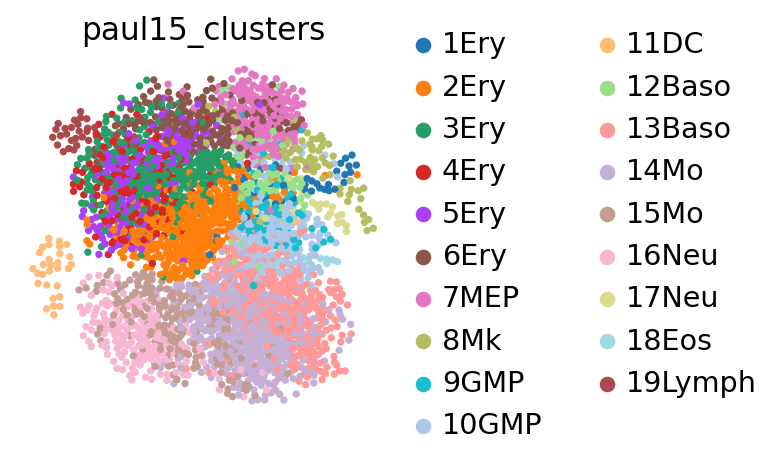

In [10]:
sc.pl.draw_graph(adata, color = "paul15_clusters", legend_loc="right margin", save = "_paul15_clusters")

In [11]:
# graph denoising

In [9]:
sc.tl.louvain(adata, resolution=1.0)

running Louvain clustering
    using the "louvain" package of Traag (2017)
    finished: found 15 clusters and added
    'louvain', the cluster labels (adata.obs, categorical) (0:00:00)


In [10]:
sc.tl.paga(adata, groups="louvain")

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


--> added 'pos', the PAGA positions (adata.uns['paga'])


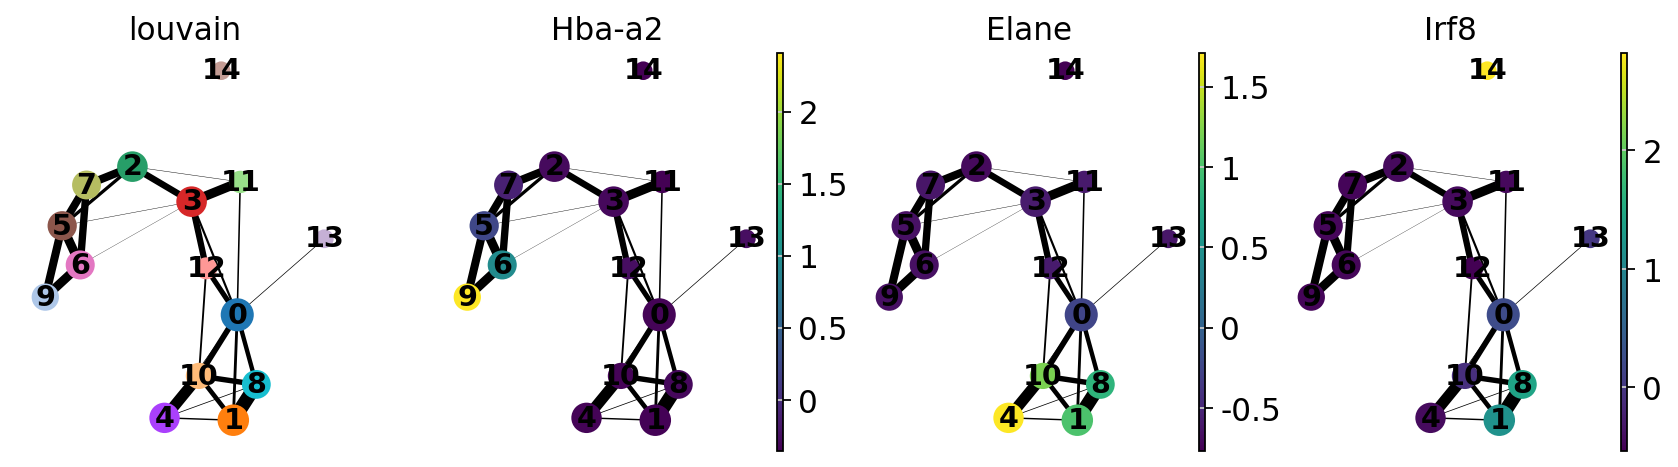

In [11]:
sc.pl.paga(adata, color=["louvain", "Hba-a2", "Elane", "Irf8"], save = "_tut_louvain_Hbaa2_Elane_Irf8")

In [3]:
adata = sc.read_h5ad("cache/adata_tutorial_trajectory.h5ad")

--> added 'pos', the PAGA positions (adata.uns['paga'])


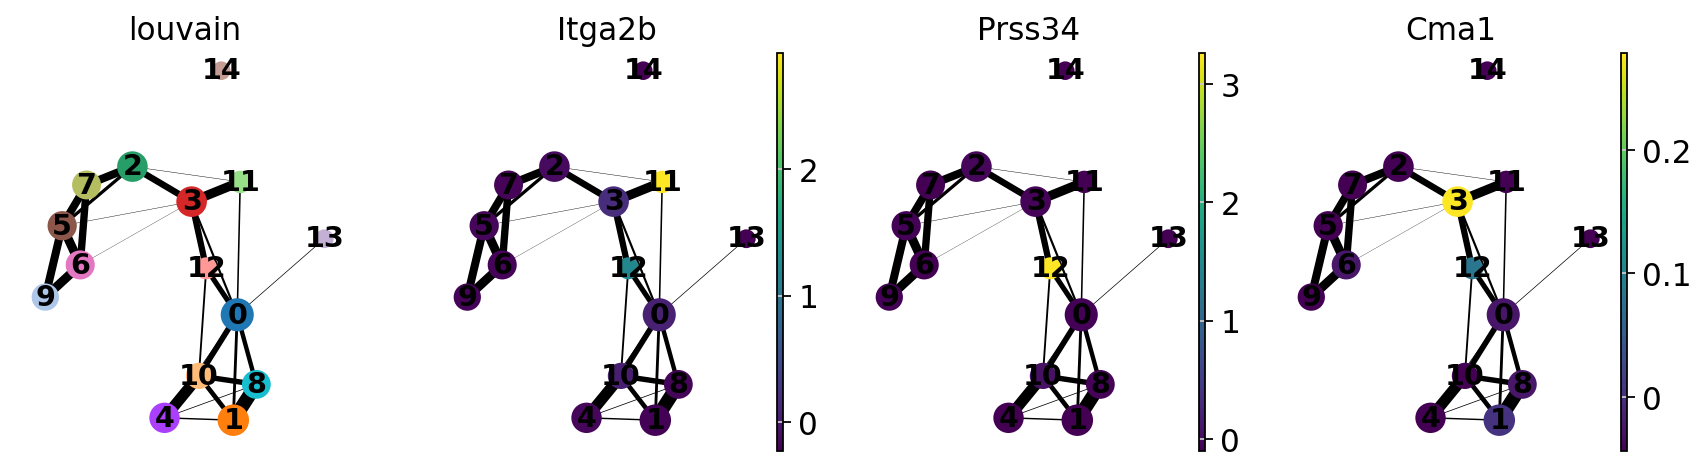

In [12]:
sc.pl.paga(adata, color=["louvain", "Itga2b", "Prss34", "Cma1"], save="_tut_louvain_Itga2b_Prss34_Cma1")

In [13]:
adata.obs["louvain"].cat.categories

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14'],
      dtype='object')

In [14]:
adata.obs["louvain_anno"] = adata.obs["louvain"].cat.rename_categories(
    {
        "3": "3/MC",
        "4": "4/Neu",
        "9": "9/Ery",
        "16": "16/Stem",
        "19": "19/Neu",
        "20": "20/Mk",
        "22": "22/Baso",
        "24": "24/Mo",
    }
)

In [15]:
sc.tl.paga(adata, groups="louvain_anno")

running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


--> added 'pos', the PAGA positions (adata.uns['paga'])


<Axes: >

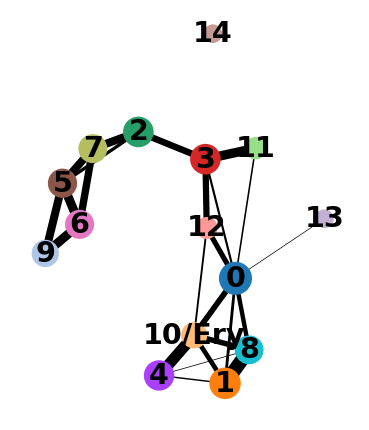

In [16]:
sc.pl.paga(adata, threshold=0.03, show=False)